In [1]:
# Radon Forecast — Random Forest Regressor с подбором гиперпараметров

# Установка зависимостей
!pip install -q scikit-learn matplotlib seaborn pandas

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json

In [3]:
# --- Загрузка и подготовка данных ---
def load_and_prepare_data(filepath):
    print("Загрузка и подготовка данных...")
    df = pd.read_csv(filepath, sep=';', decimal=',', encoding='latin-1')
    df['Datetime'] = pd.to_datetime(df['Datetime'], format="%d.%m.%Y %H:%M")
    df.set_index('Datetime', inplace=True)
    df = df.sort_index().interpolate(method='time')
    return df

In [4]:
def split_and_scale_data(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    train_size = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns

In [5]:
# --- Поиск гиперпараметров ---
def tune_random_forest(X_train, y_train):
    param_dist = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    }
    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                                param_distributions=param_dist,
                                n_iter=30, cv=tscv, scoring='neg_mean_squared_error',
                                n_jobs=-1, verbose=1, random_state=42)
    search.fit(X_train, y_train)
    return search

In [6]:
# --- Основной скрипт ---
df = load_and_prepare_data("/content/data.csv")
TARGET = 'Radon (Bq.m3)'
X_train_scaled, X_test_scaled, y_train, y_test, feature_names = split_and_scale_data(df, TARGET)

Загрузка и подготовка данных...


In [7]:
search = tune_random_forest(X_train_scaled, y_train)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

In [8]:
# --- Метрики ---
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Лучшие параметры: {search.best_params_}")
print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

Лучшие параметры: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
MSE: 89146354.92, MAE: 8158.59, R2: -0.21


In [9]:
metrics = {
    "best_params": search.best_params_,
    "test_mse": mse,
    "test_mae": mae,
    "test_r2": r2
}
with open("random_forest_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

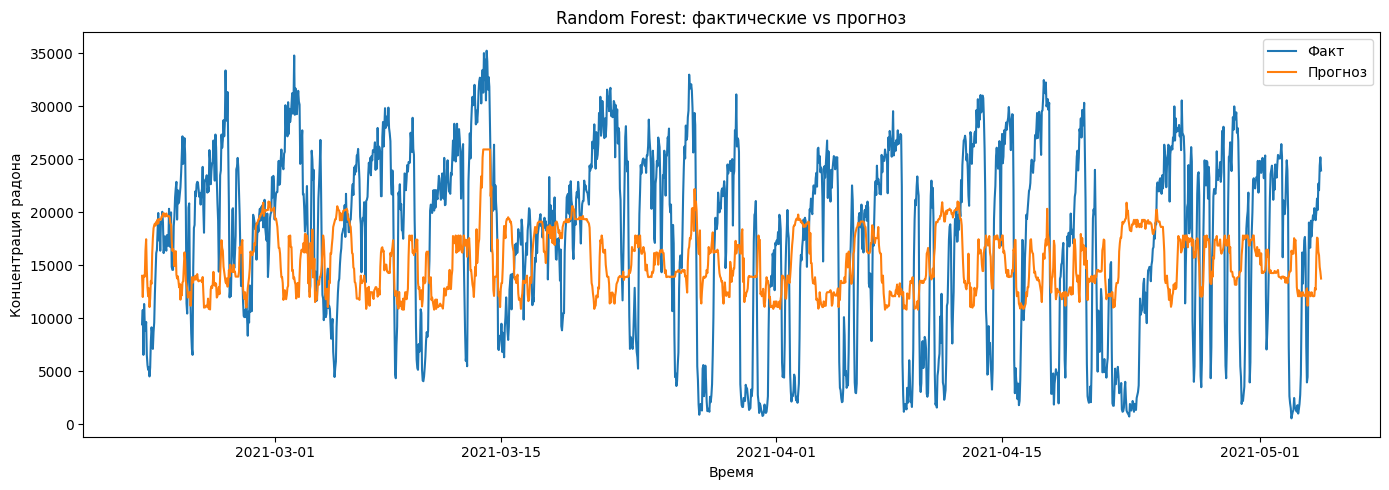

In [10]:
# --- Визуализация прогноза ---
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Факт')
plt.plot(y_test.index, y_pred, label='Прогноз')
plt.title("Random Forest: фактические vs прогноз")
plt.xlabel("Время")
plt.ylabel("Концентрация радона")
plt.legend()
plt.tight_layout()
plt.savefig("random_forest_forecast.jpeg")
plt.show()

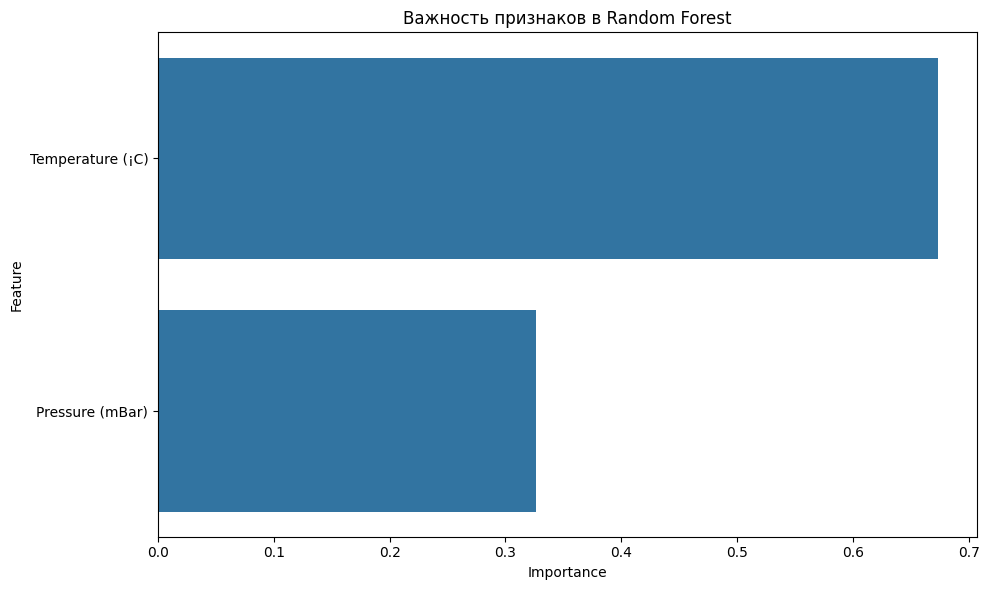

In [11]:
# --- Визуализация важности признаков ---
importances = best_model.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df.sort_values("Importance", ascending=False), x="Importance", y="Feature")
plt.title("Важность признаков в Random Forest")
plt.tight_layout()
plt.savefig("random_forest_feature_importance.jpeg")
plt.show()